<a href="https://colab.research.google.com/github/varshini2427/Data-Analytics-using-Python-Project/blob/main/mainproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- 1. Raw Dataset Loaded ---
   Patient ID  Age Disease Category Admission Date
0         101   23              Flu     2026-01-10
1         102   65         Diabetes     2026-01-15
2         103   45              Flu     2026-05-12
3         104   71     Heart Attack     2026-05-14
4         105   12              Flu     2026-01-11
5         106   34         Diabetes     2026-03-20
6         107   68     Heart Attack     2026-03-22
7         108    8              Flu     2026-06-05
8         109   52         Diabetes     2026-06-18
9         110   29              Flu     2026-01-25 

--- 2. Preprocessed & Structured Dataset ---
   Patient ID  Age Disease Category Admission Date       Age Group  \
0         101   23              Flu     2026-01-10           Adult   
1         102   65         Diabetes     2026-01-15  Senior Citizen   
2         103   45              Flu     2026-05-12           Adult   
3         104   71     Heart Attack     2026-05-14  Senior Citizen   
4         10

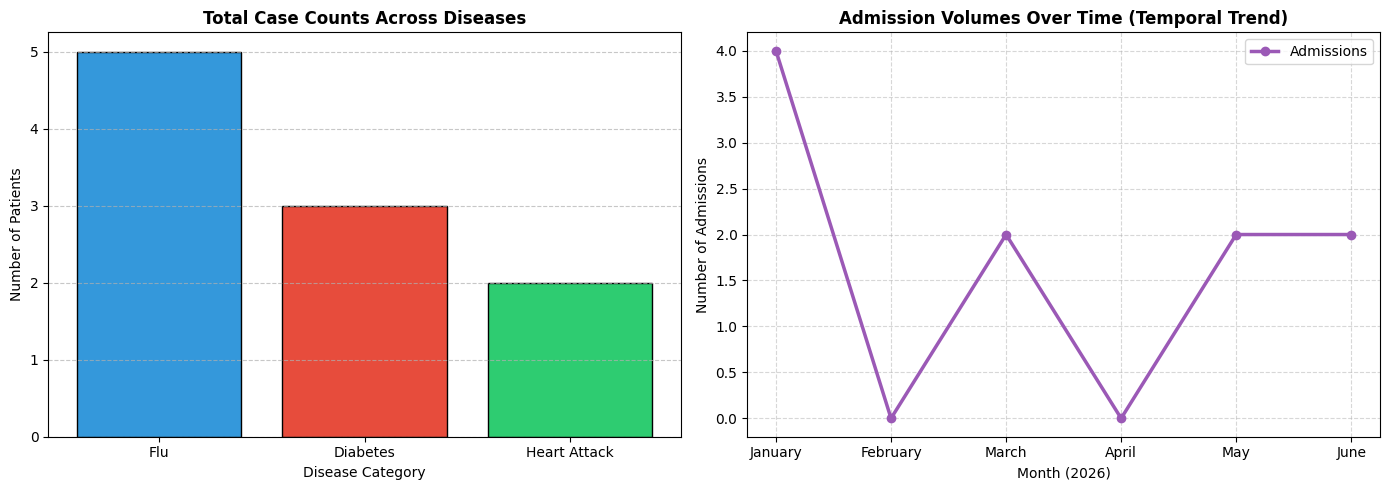

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- STEP 1: DATA INGESTION ---
raw_data = {
    "Patient ID": [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    "Age": [23, 65, 45, 71, 12, 34, 68, 8, 52, 29],
    "Disease Category": [
        "Flu",
        "Diabetes",
        "Flu",
        "Heart Attack",
        "Flu",
        "Diabetes",
        "Heart Attack",
        "Flu",
        "Diabetes",
        "Flu",
    ],
    "Admission Date": [
        "2026-01-10",
        "2026-01-15",
        "2026-05-12",
        "2026-05-14",
        "2026-01-11",
        "2026-03-20",
        "2026-03-22",
        "2026-06-05",
        "2026-06-18",
        "2026-01-25",
    ],
}

# Loading into Pandas DataFrame
df = pd.DataFrame(raw_data)
print("--- 1. Raw Dataset Loaded ---")
print(df, "\n")


# --- STEP 2: DATA PREPROCESSING & CLEANING ---
df["Admission Date"] = pd.to_datetime(df["Admission Date"])

# Vectorized function for Custom Age Categorization (Optimized .apply Method)
def categorize_age(age):
    if age < 18:
        return "Child"
    elif age <= 60:
        return "Adult"
    else:
        return "Senior Citizen"


df["Age Group"] = df["Age"].apply(categorize_age)

# Temporal Chronological Evaluation: Extracting Month Name
df["Admission Month"] = df["Admission Date"].dt.strftime("%B")

print("--- 2. Preprocessed & Structured Dataset ---")
print(df, "\n")


# --- STEP 3 & 4: EXPLORATORY DATA AGGREGATION & TEMPORAL EVALUATION ---
# Count records grouped by specific diseases
disease_counts = df["Disease Category"].value_counts()

# Peak admission frequencies over months (Sorting by chronological order)
month_order = ["January", "February", "March", "April", "May", "June"]
df["Admission Month"] = pd.Categorical(
    df["Admission Month"], categories=month_order, ordered=True
)
monthly_admissions = (
    df.groupby("Admission Month", observed=False).size().reset_index(name="Count")
)

print("--- 3. Aggregated Disease Counts ---")
print(disease_counts.to_string(), "\n")

print("--- 4. Monthly Admission Trends ---")
print(monthly_admissions.to_string(index=False), "\n")


# --- STEP 5: VISUALIZATION GENERATION (DASHBOARD LAYOUT) ---
# Side-by-side dashboard layout configured using multi-axis subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar Chart displaying total case counts across diseases
axes[0].bar(
    disease_counts.index,
    disease_counts.values,
    color=["#3498db", "#e74c3c", "#2ecc71"],
    edgecolor="black",
)
axes[0].set_title("Total Case Counts Across Diseases", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Disease Category", fontsize=10)
axes[0].set_ylabel("Number of Patients", fontsize=10)
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# Plot 2: Connected Line Graph tracking admission volumes over time
axes[1].plot(
    monthly_admissions["Admission Month"],
    monthly_admissions["Count"],
    marker="o",
    linewidth=2.5,
    color="#9b59b6",
    label="Admissions",
)
axes[1].set_title(
    "Admission Volumes Over Time (Temporal Trend)", fontsize=12, fontweight="bold"
)
axes[1].set_xlabel("Month (2026)", fontsize=10)
axes[1].set_ylabel("Number of Admissions", fontsize=10)
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend()

# Tight layout and rendering
plt.tight_layout()
plt.show()